## Section 1: Setup & Environment

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from transformers import Sam2Processor, Sam2Model
from PIL import Image

/home/cagan/open-vocab-perception/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 2: Model Loading & VRAM Profile

In [2]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

mem_before = torch.cuda.memory_allocated() / 1024**2

MODEL_ID = "facebook/sam2.1-hiera-tiny"   # smallest varient, ~38M params
# alternative: "facebook/sam2.1-hiera-small" (~46M)
# alternative: "facebook/sam2.1-hiera-base-plus" (~80M)
DEVICE = "cuda"

print("Loading processor...")
processor = Sam2Processor.from_pretrained(MODEL_ID)

print("Loading model (first run downloads ~700MB)...")
model = Sam2Model.from_pretrained(MODEL_ID).to(DEVICE)
model.eval()

mem_after = torch.cuda.memory_allocated() / 1024**2
print(f"\nVRAM used by model: {mem_after - mem_before:.1f} MB")
print(f"Total VRAM allocated: {mem_after:.1f} MB")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

Loading processor...
Loading model (first run downloads ~700MB)...


You are using a model of type sam2_video to instantiate a model of type sam2. This is not supported for all configurations of models and can yield errors.



VRAM used by model: 121.1 MB
Total VRAM allocated: 121.1 MB
Model parameters: 31.4M


## Section 3: First Inference — Box Prompt

In [3]:
import requests
from io import BytesIO

url = "http://images.cocodataset.org/val2017/000000039769.jpg"  # cats
image_pil = Image.open(BytesIO(requests.get(url).content)).convert("RGB")

# Manuel box prompt (for the left cat)
input_boxes = [[[10, 50, 320, 480]]]  # batch=1, num_boxes=1, [x1,y1,x2,y2]

inputs = processor(image_pil, input_boxes=input_boxes, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    outputs = model(**inputs)

# Mask post-process
masks = processor.post_process_masks(
    outputs.pred_masks.cpu(),
    original_sizes=inputs["original_sizes"].cpu(),
    reshaped_input_sizes=inputs["reshaped_input_sizes"].cpu(),
)

In [5]:
best_idx = torch.argmax(outputs.iou_scores[0, 0])
selected_mask = masks[0][0, best_idx] # shape: (H, W)

print(f"masks type: {type(masks)}")
print(f"masks length: {len(masks)}")
print(f"masks[0] shape: {masks[0].shape}")
print(f"iou_scores shape: {outputs.iou_scores.shape}")
print(f"iou_scores values: {outputs.iou_scores}")
print("="*20)
print(f"mask dtype: {selected_mask.dtype}")
print(f"mask min: {selected_mask.min()}, max: {selected_mask.max()}")
print(f"mask unique values count: {selected_mask.unique().numel()}")

masks type: <class 'list'>
masks length: 1
masks[0] shape: torch.Size([1, 3, 480, 640])
iou_scores shape: torch.Size([1, 1, 3])
iou_scores values: tensor([[[0.9512, 0.9520, 0.9740]]], device='cuda:0')
mask dtype: torch.bool
mask min: False, max: True
mask unique values count: 2


## Section 4: Visualization & Analysis

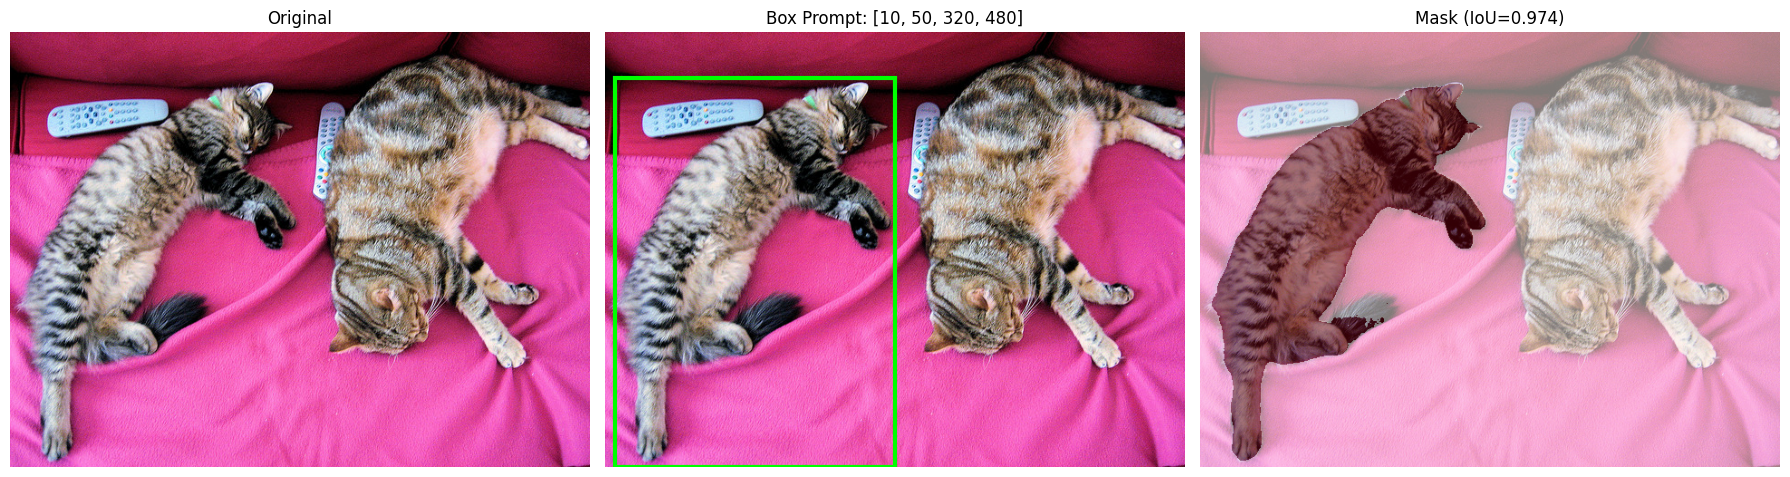

In [ ]:
# Bbox uncpacking
x1, y1, x2, y2 = input_boxes[0][0]

# Select best mask and convert it to numpy
best_idx = torch.argmax(outputs.iou_scores[0, 0]).item()
best_score = outputs.iou_scores[0, 0, best_idx].item()
mask_np = masks[0][0, best_idx].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 0: Original
axes[0].imshow(image_pil)
axes[0].set_title("Original")
axes[0].axis("off")

# Subplot 1: Box prompt
axes[1].imshow(image_pil)
rect = patches.Rectangle(
    (x1, y1), 
    x2 - x1, 
    y2 - y1, 
    edgecolor='lime', 
    linewidth=3, 
    facecolor='none'
)
axes[1].add_patch(rect)
axes[1].set_title(f"Box Prompt: [{x1}, {y1}, {x2}, {y2}]")
axes[1].axis("off")

# Subplot 2: Mask overlay
axes[2].imshow(image_pil)
axes[2].imshow(mask_np, alpha=0.5, cmap='Reds')
axes[2].set_title(f"Mask (IoU={best_score:.3f})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Section 5: Multi Box Inference

outputs.iou_scores shape: torch.Size([1, 2, 3])
masks[0] shape: torch.Size([2, 3, 480, 640])


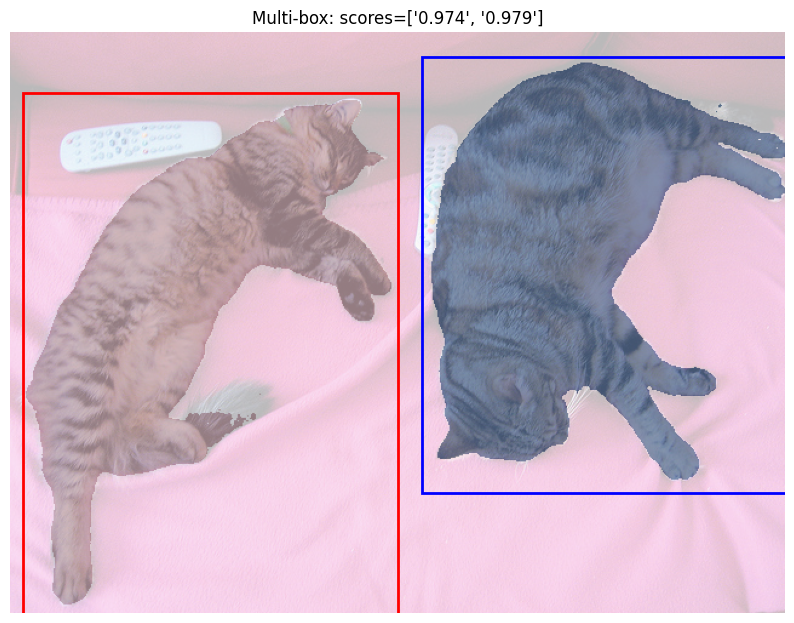

In [8]:
input_boxes = [[
    [10, 50, 320, 480],           # left cat
    [340, 20, 640, 380],          # right cat
]]  # batch=1, num_boxes=2

# New inputs and masks
inputs = processor(image_pil, input_boxes=input_boxes, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    outputs = model(**inputs)
masks = processor.post_process_masks(
    outputs.pred_masks.cpu(),
    original_sizes=inputs["original_sizes"].cpu(),
    reshaped_input_sizes=inputs["reshaped_input_sizes"].cpu(),
)

# Sanity check — shape'leri öğren
print(f"outputs.iou_scores shape: {outputs.iou_scores.shape}")  # (1, 2, 3)
print(f"masks[0] shape: {masks[0].shape}")                      # (2, 3, H, W)

# Select best masks and scores
num_boxes = len(input_boxes[0])
selected_masks = []
selected_scores = []
for box_idx in range(num_boxes):
    best_idx = torch.argmax(outputs.iou_scores[0, box_idx]).item()
    best_score = outputs.iou_scores[0, box_idx, best_idx].item()
    mask_np = masks[0][box_idx, best_idx].cpu().numpy()
    selected_masks.append(mask_np)
    selected_scores.append(best_score)

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(image_pil)

# Different color for every mask
cmaps = ['Reds', 'Blues']

for mask_np, score, cmap in zip(selected_masks, selected_scores, cmaps):
    ax.imshow(mask_np, alpha=0.5, cmap=cmap)

# Overlay bboxes with different colors
colors = ['red', 'blue']
for (x1, y1, x2, y2), color in zip(input_boxes[0], colors):
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                             edgecolor=color, linewidth=2, facecolor='none')
    ax.add_patch(rect)

ax.set_title(f"Multi-box: scores={[f'{s:.3f}' for s in selected_scores]}")
ax.axis("off")
plt.show()

## Section 6: Latency Benchmark

In [9]:
import time

bbox_counts = [1, 2, 4]
results_per_count = {}

for n in bbox_counts:
    # n adet bbox prep et — aynı bbox'ı n kez tekrarlayabilirsin sandbox için
    test_boxes = [[[10, 50, 320, 480]] * n]  # batch=1, n boxes
    
    test_inputs = processor(image_pil, input_boxes=test_boxes, return_tensors="pt").to(DEVICE)
    
    # Warmup (3 run)
    for _ in range(3):
        with torch.no_grad():
            _ = model(**test_inputs)
    
    torch.cuda.synchronize()
    
    # Benchmark (20 runs)
    times = []
    for _ in range(20):
        torch.cuda.synchronize()
        start = time.perf_counter()
        with torch.no_grad():
            _ = model(**test_inputs)
        torch.cuda.synchronize()
        times.append((time.perf_counter() - start) * 1000)
    
    times = np.array(times)
    results_per_count[n] = {
        'mean': times.mean(),
        'std': times.std(),
        'fps': 1000 / times.mean()
    }
    print(f"n_boxes={n}: mean={times.mean():.1f}ms, std={times.std():.1f}ms, ~{1000/times.mean():.1f} FPS")

n_boxes=1: mean=147.8ms, std=0.6ms, ~6.8 FPS
n_boxes=2: mean=151.9ms, std=0.6ms, ~6.6 FPS
n_boxes=4: mean=160.1ms, std=0.3ms, ~6.2 FPS


## Section 7: Observations & Pipeline Implications

**Test setup:** SAM 2.1 Hiera-tiny (31.4M params, 121MB VRAM) on RTX 3050 Ti,
fp32. Test image: COCO val2017 cats with manual box prompts.

**Mask quality:**
- The mask followed the cat's silhouette quite well when given a single bbox prompt.
- Fine details like the tail, legs, and ears captured accurately.
- Leakage didn't occur outside the bbox, even when the prompt was loose.
- The mask stayed tight even when the bbox prompt was loose.

**Multi-mask selection:**
- The typical range of iou_scores is 0.95+
- The argmax(iou_score) strategy worked well across the sandbox examples.
- The 3 mask alternatives genuinely different interpretations.

**Multi-box behavior (from Section 5):**
- When two bboxes were given for two separate cats, every bbox localized it's own cat well, with minimal cross-talk.

**Latency scaling (from Section 6, if measured):**
- The average ms values for 1, 2, and 4 bboxes are 147.8ms, 151.9ms, and 160.1ms respectively.
- Latency scaled sublinearly with bbox count (4x more bboxes added only ~8% latency).
- This indicates the image encoder dominates compute cost; mask decoder per-bbox overhead is minimal.

**Pipeline implications:**
1. Combined detector (~433.9ms) + segmenter (~160.1ms) ≈ 594 ms per frame, ≈ 1.7 FPS. This is below real-time threshold. Therefore VideoPipeline should use a keyframe strategy: run GroundingDINO every 10 frames, propagate masks/boxes between keyframes via SAM 2 memory or tracker.
2. Total static VRAM ≈ 458MB on 4GB card. ~3.5GB headroom for activations and intermediate tensors. Both models can coexist on GPU; no offloading required for current setup. Future scaling to base-plus variants (~200MB segmenter) still leaves ~3GB headroom.
3. SAM 2's promptable architecture decouples image encoding (~140ms, runs once) from mask decoding (~4ms per bbox, scales with prompt count). This means dense scenes with many detections do not blow up segmenter latency. Pipeline can confidently scale to 10-20 detections per frame without significant slowdown.

**Comparison with GroundingDINO:**
- Param count: 31.4M (SAM 2) vs 172M (GroundingDINO) — 5x smaller
- VRAM: 121MB vs 337MB — 3x smaller
- GroundingDINO outputs bounding boxes + text labels (open-vocabulary detection). SAM 2 outputs pixel masks given spatial prompts (class-agnostic segmentation). They are complementary: detector provides 'what & where (coarse)', segmenter provides 'precise pixel boundary'. Neither alone delivers open-vocabulary segmentation; the pipeline composition is the value.